# Sequence Encoder Comparison: Lorenz Attractor from Partial Observations

This notebook compares several sequence autoencoder architectures for
reconstructing the Lorenz attractor from **partial observations** (only
the $x$ coordinate).

Instead of requiring a hand-tuned delay embedding, each architecture
takes a raw $(T, D)$ window and encodes it into an $N$-dimensional latent
space, which is then decoded to **reconstruct the full input window**.

**Architectures tested:**
1. Transformer (no positional encoding)
2. Transformer (with positional encoding)
3. State Space Model / S4 (no positional encoding)
4. State Space Model / S4 (with positional encoding)
5. Temporal Convolutional Network (TCN)
6. TCN + Spatial Convolutions

All models use **FNN regularization** on the $N$-dimensional latent.

In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
from collections import OrderedDict

from JacobianODE.dysts_sim.flows import Lorenz
from JacobianODE.fnn import (
    TransformerEmbedding,
    SSMEmbedding,
    TCNEmbedding,
    TCNSpatialEmbedding,
    FNN,
    compute_variances,
    compute_s_dim,
)

plt.rcParams.update({
    'figure.figsize': (12, 4),
    'font.size': 11,
})

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


## 1. Generate Lorenz Data

In [3]:
# Generate Lorenz trajectories
lorenz = Lorenz()
data_dict = lorenz.make_trajectory(
    n_periods=12,
    pts_per_period=100,
    num_ics=16,
    new_ic_mode='random',
    traj_offset_sd=0.2,
    return_times=True,
)

full_data = data_dict['values']  # (num_ics, T, 3)
dt = data_dict['dt']
print(f'Full data shape: {full_data.shape}, dt = {dt:.4f}')

# Add small observation noise
obs_noise = 0.01
np.random.seed(42)
full_data_noisy = full_data + obs_noise * np.random.randn(*full_data.shape)

# Partial observation: only x coordinate (D=1)
partial_data = full_data_noisy[:, :, [0]]  # (num_ics, T, 1)
print(f'Partial observation shape: {partial_data.shape}')

# Train / test split by initial conditions
n_train = 12
train_data = partial_data[:n_train]
test_data = partial_data[n_train:]
train_full = full_data_noisy[:n_train]
test_full = full_data_noisy[n_train:]
print(f'Train: {train_data.shape}, Test: {test_data.shape}')

Full data shape: (16, 1200, 3), dt = 0.0150
Partial observation shape: (16, 1200, 1)
Train: (12, 1200, 1), Test: (4, 1200, 1)


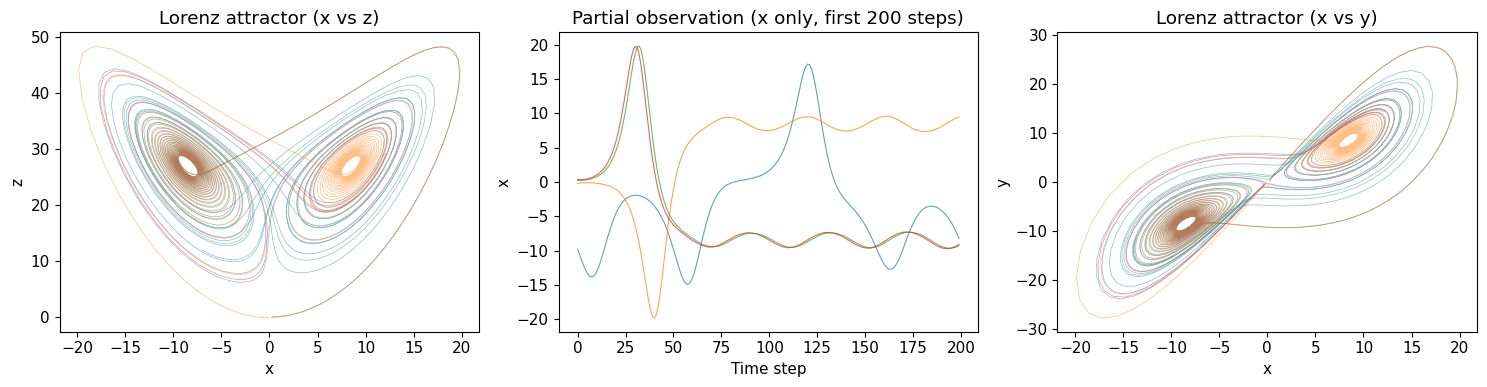

In [4]:
# Visualize the Lorenz attractor and partial observation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 3D projection (x vs z)
for i in range(min(4, n_train)):
    axes[0].plot(train_full[i, :, 0], train_full[i, :, 2], alpha=0.5, lw=0.5)
axes[0].set_xlabel('x'); axes[0].set_ylabel('z')
axes[0].set_title('Lorenz attractor (x vs z)')

# Partial observation time series
for i in range(min(4, n_train)):
    axes[1].plot(train_data[i, :200, 0], alpha=0.7, lw=0.8)
axes[1].set_xlabel('Time step'); axes[1].set_ylabel('x')
axes[1].set_title('Partial observation (x only, first 200 steps)')

# x-y phase space
for i in range(min(4, n_train)):
    axes[2].plot(train_full[i, :, 0], train_full[i, :, 1], alpha=0.5, lw=0.5)
axes[2].set_xlabel('x'); axes[2].set_ylabel('y')
axes[2].set_title('Lorenz attractor (x vs y)')

plt.tight_layout()
plt.show()

## 2. Define Architectures and Hyperparameters

In [7]:
# Shared hyperparameters
N_LATENT = 10          # Latent dimension (Lorenz has 3 dims, but we give extra capacity)
TIME_WINDOW = 64      # Input sequence length
N_FEATURES = 1        # Partial observation dimension (x only)
FNN_STRENGTH = 0.1   # FNN regularization strength
# TRAIN_STEPS = 200     # Training epochs
TRAIN_STEPS = 50        # Training epochs
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
SEED = 42

fnn_reg = FNN(FNN_STRENGTH)

# Define all model configurations
model_configs = OrderedDict([
    ('Transformer (no PE)', {
        'class': TransformerEmbedding,
        'kwargs': dict(
            use_positional_encoding=False,
            d_model=64, n_heads=4, n_layers=3,
            dim_feedforward=128, dropout=0.1,
        ),
    }),
    ('Transformer (PE)', {
        'class': TransformerEmbedding,
        'kwargs': dict(
            use_positional_encoding=True,
            d_model=64, n_heads=4, n_layers=3,
            dim_feedforward=128, dropout=0.1,
        ),
    }),
    ('SSM (no PE)', {
        'class': SSMEmbedding,
        'kwargs': dict(
            use_positional_encoding=False,
            d_model=64, d_state=64, n_layers=3, dropout=0.1,
        ),
    }),
    ('SSM (PE)', {
        'class': SSMEmbedding,
        'kwargs': dict(
            use_positional_encoding=True,
            d_model=64, d_state=64, n_layers=3, dropout=0.1,
        ),
    }),
    ('TCN', {
        'class': TCNEmbedding,
        'kwargs': dict(
            n_channels=64, kernel_size=7, n_layers=4, dropout=0.1,
        ),
    }),
    ('TCN + Spatial', {
        'class': TCNSpatialEmbedding,
        'kwargs': dict(
            n_channels=64, kernel_size_temporal=7,
            kernel_size_spatial=3, n_layers=4, dropout=0.1,
        ),
    }),
])

print(f'{len(model_configs)} architectures to compare')

6 architectures to compare


## 3. Train All Models

In [8]:
results = OrderedDict()

for name, cfg in model_configs.items():
    print(f'\n{"="*60}')
    print(f'Training: {name}')
    print(f'{"="*60}')

    model = cfg['class'](
        n_latent=N_LATENT,
        time_window=TIME_WINDOW,
        n_features=N_FEATURES,
        random_state=SEED,
        latent_regularizer=FNN(FNN_STRENGTH),
        **cfg['kwargs'],
    )

    t0 = time.time()
    model.fit(
        train_data,
        train_steps=TRAIN_STEPS,
        batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        verbose=1,
        optimizer='adamw',
    )
    train_time = time.time() - t0

    # Evaluate reconstruction on test set
    recon = model.reconstruct(test_data)       # (n_windows, TIME_WINDOW, 1)
    latent = model.transform(test_data)        # (n_windows, TIME_WINDOW, N_LATENT)

    # Compute reconstruction MSE against standardized input windows
    from JacobianODE.fnn.sequence_models import sliding_windows
    test_std = model._standardize(test_data)
    x_true = sliding_windows(test_std, TIME_WINDOW)
    mse = float(np.mean((recon - x_true) ** 2))

    # Flatten per-timestep latent for variance analysis: (n_windows, T, D') -> (n_windows*T, D')
    latent_flat = latent.reshape(-1, latent.shape[-1])
    norm_var = compute_variances(latent_flat, normalize=True)

    results[name] = {
        'model': model,
        'mse': mse,
        'norm_var': norm_var,
        'latent': latent,
        'recon': recon,
        'x_true': x_true,
        'train_time': train_time,
        'n_params': model.count_parameters(),
        'history': model.train_history,
    }

    print(f'  Test Recon MSE: {mse:.6f}')
    print(f'  Params:   {model.count_parameters():,}')
    print(f'  Time:     {train_time:.1f}s')

print(f'\nAll {len(results)} models trained.')


Training: Transformer (no PE)
Epoch 1/50 - loss: 0.046330  recon: 0.032664  reg: 0.013666
Epoch 3/50 - loss: 0.001415  recon: 0.000834  reg: 0.000581
Epoch 5/50 - loss: 0.000676  recon: 0.000471  reg: 0.000204
Epoch 7/50 - loss: 0.000329  recon: 0.000222  reg: 0.000107
Epoch 9/50 - loss: 0.000805  recon: 0.000714  reg: 0.000090
Epoch 11/50 - loss: 0.000153  recon: 0.000103  reg: 0.000050
Epoch 13/50 - loss: 0.000239  recon: 0.000199  reg: 0.000040
Epoch 15/50 - loss: 0.000129  recon: 0.000099  reg: 0.000031
Epoch 17/50 - loss: 0.000149  recon: 0.000122  reg: 0.000026
Epoch 19/50 - loss: 0.000233  recon: 0.000210  reg: 0.000023
Epoch 21/50 - loss: 0.000068  recon: 0.000051  reg: 0.000018
Epoch 23/50 - loss: 0.000065  recon: 0.000049  reg: 0.000016
Epoch 25/50 - loss: 0.000059  recon: 0.000046  reg: 0.000014
Epoch 27/50 - loss: 0.000076  recon: 0.000063  reg: 0.000012
Epoch 29/50 - loss: 0.000058  recon: 0.000047  reg: 0.000011
Epoch 31/50 - loss: 0.000044  recon: 0.000034  reg: 0.00001

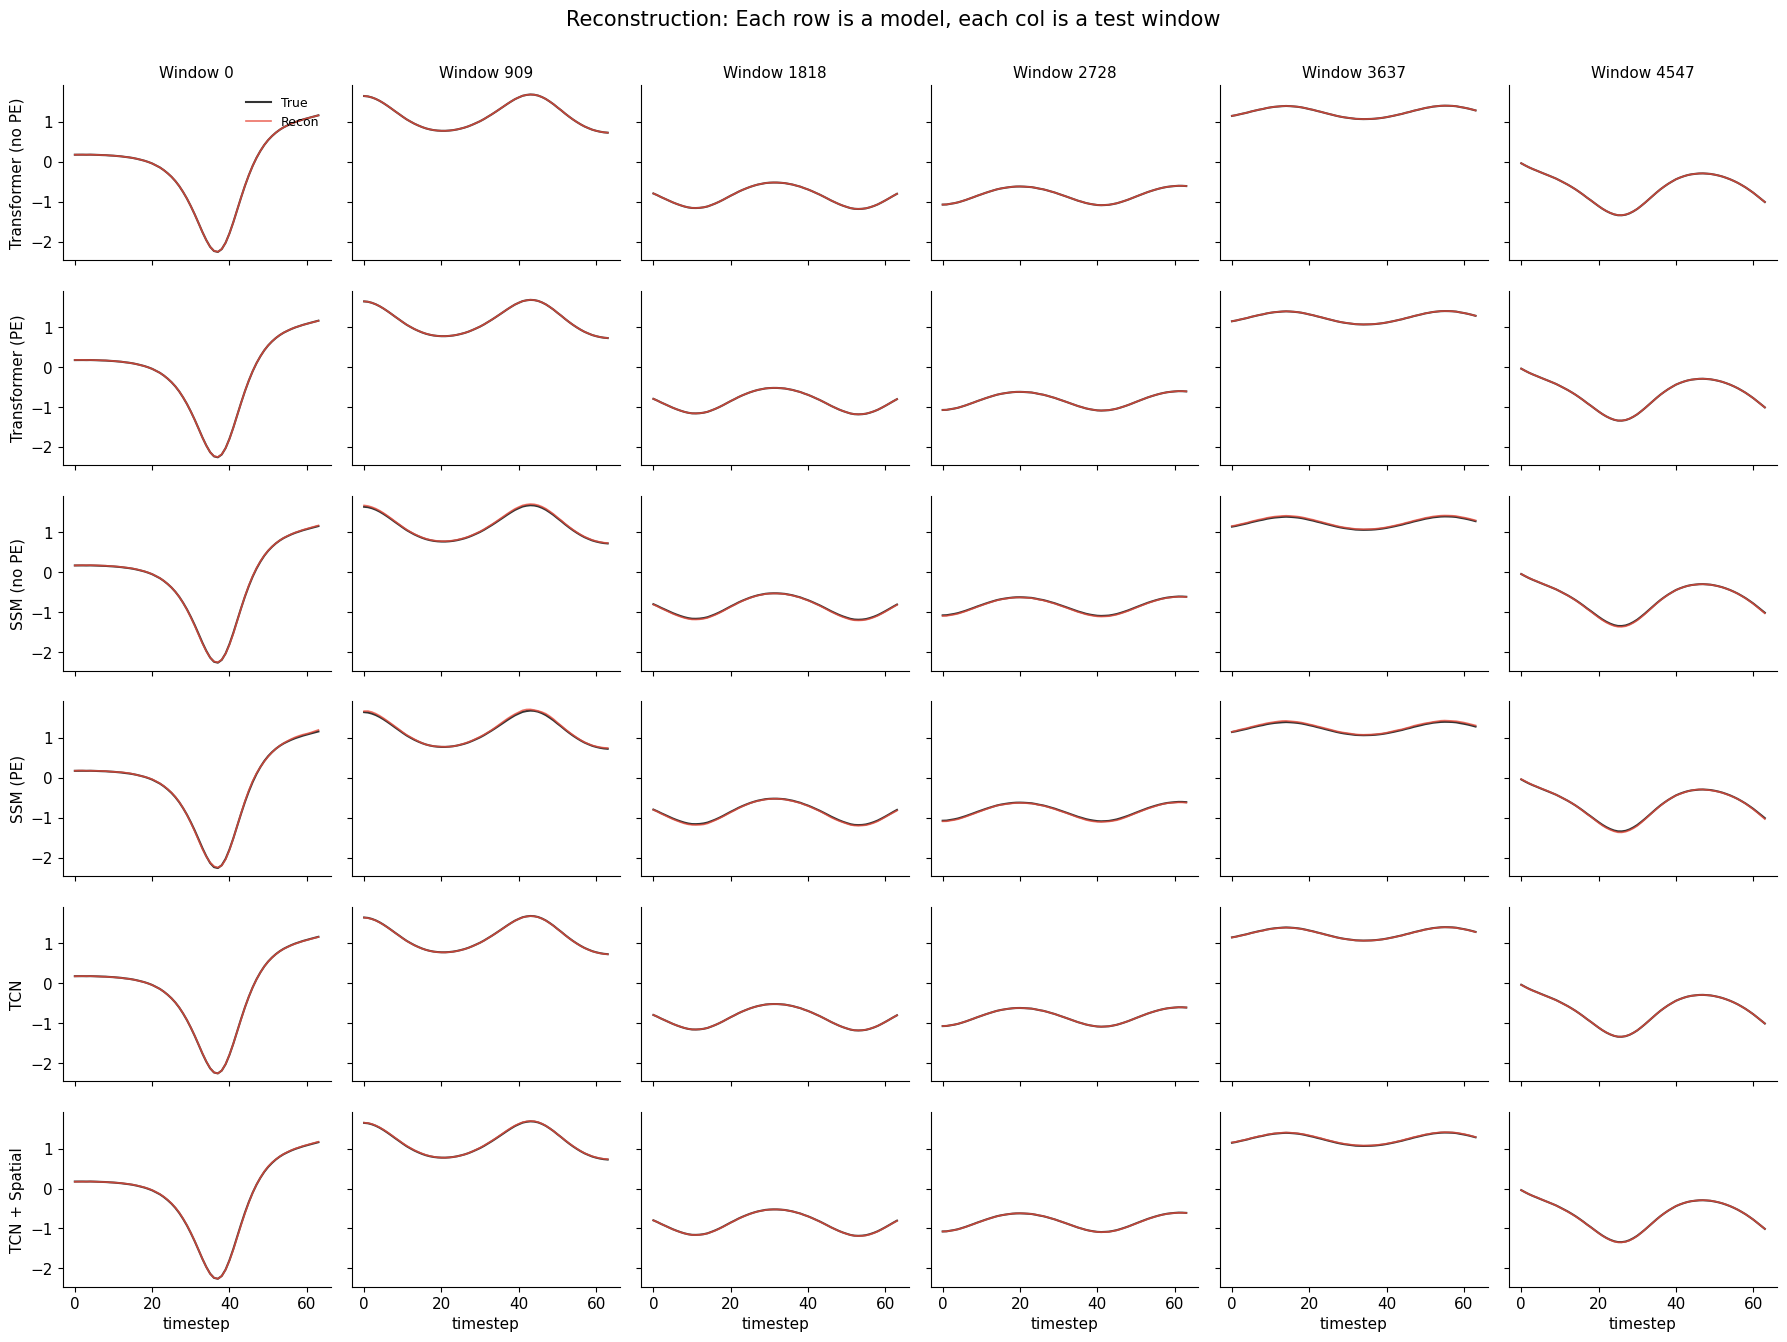

In [13]:
# 6x6 grid: rows = models, cols = randomly picked 6 test windows
import matplotlib.pyplot as plt
import numpy as np

model_names = list(results.keys())
n_models = len(model_names)
n_examples = 6

# Pick 6 uniformly spaced test indices for demonstration (assume n_windows >= n_examples)
n_windows = results[model_names[0]]['x_true'].shape[0]
if n_windows < n_examples:
    example_idxs = np.arange(n_windows)
else:
    example_idxs = np.linspace(0, n_windows-1, n_examples, dtype=int)

time_axis = np.arange(results[model_names[0]]['x_true'].shape[1])

fig, axes = plt.subplots(n_models, n_examples, figsize=(18, 13), sharex='col', sharey='all')
if axes.ndim == 1:  # Handle edge case if n_models or n_examples == 1
    axes = axes.reshape(n_models, n_examples)

for row, name in enumerate(model_names):
    recon = results[name]['recon']      # (n_windows, T, D)
    x_true = results[name]['x_true']    # (n_windows, T, D)
    # squeeze D=1 for plotting
    if recon.shape[-1] == 1:
        recon = recon.squeeze(-1)
    if x_true.shape[-1] == 1:
        x_true = x_true.squeeze(-1)
    for col, idx in enumerate(example_idxs):
        ax = axes[row, col]
        ax.plot(time_axis, x_true[idx], label='True', color='black', linewidth=1.5, alpha=0.8)
        ax.plot(time_axis, recon[idx], label='Recon', color='#e74c3c', linewidth=1.2, alpha=0.8)
        if row == 0:
            ax.set_title(f'Window {idx}', fontsize=11)
        if col == 0:
            ax.set_ylabel(name, fontsize=11)
        if row == n_models - 1:
            ax.set_xlabel('timestep')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if row == 0 and col == 0:
            ax.legend(frameon=False, fontsize=9, loc='upper right')

plt.tight_layout(h_pad=1.7)
plt.suptitle('Reconstruction: Each row is a model, each col is a test window', fontsize=15, y=1.03)
plt.show()

In [22]:
test_full.reshape(-1, 3)

array([[-1.18683043e-01, -1.90739518e-02, -5.04508056e-01],
       [-1.11819945e-01, -6.89674463e-02, -4.89141010e-01],
       [-1.07684851e-01, -1.03428191e-01, -4.69246560e-01],
       ...,
       [-8.46511579e+00, -1.25908050e+01,  2.01550788e+01],
       [-9.09849215e+00, -1.33744225e+01,  2.10514426e+01],
       [-9.73306591e+00, -1.40509789e+01,  2.21252995e+01]],
      shape=(4800, 3))

In [26]:
test_data.shape

(4, 1200, 1)

In [25]:
results["Transformer (no PE)"]['model'].transform(test_data).shape

(4548, 64, 10)

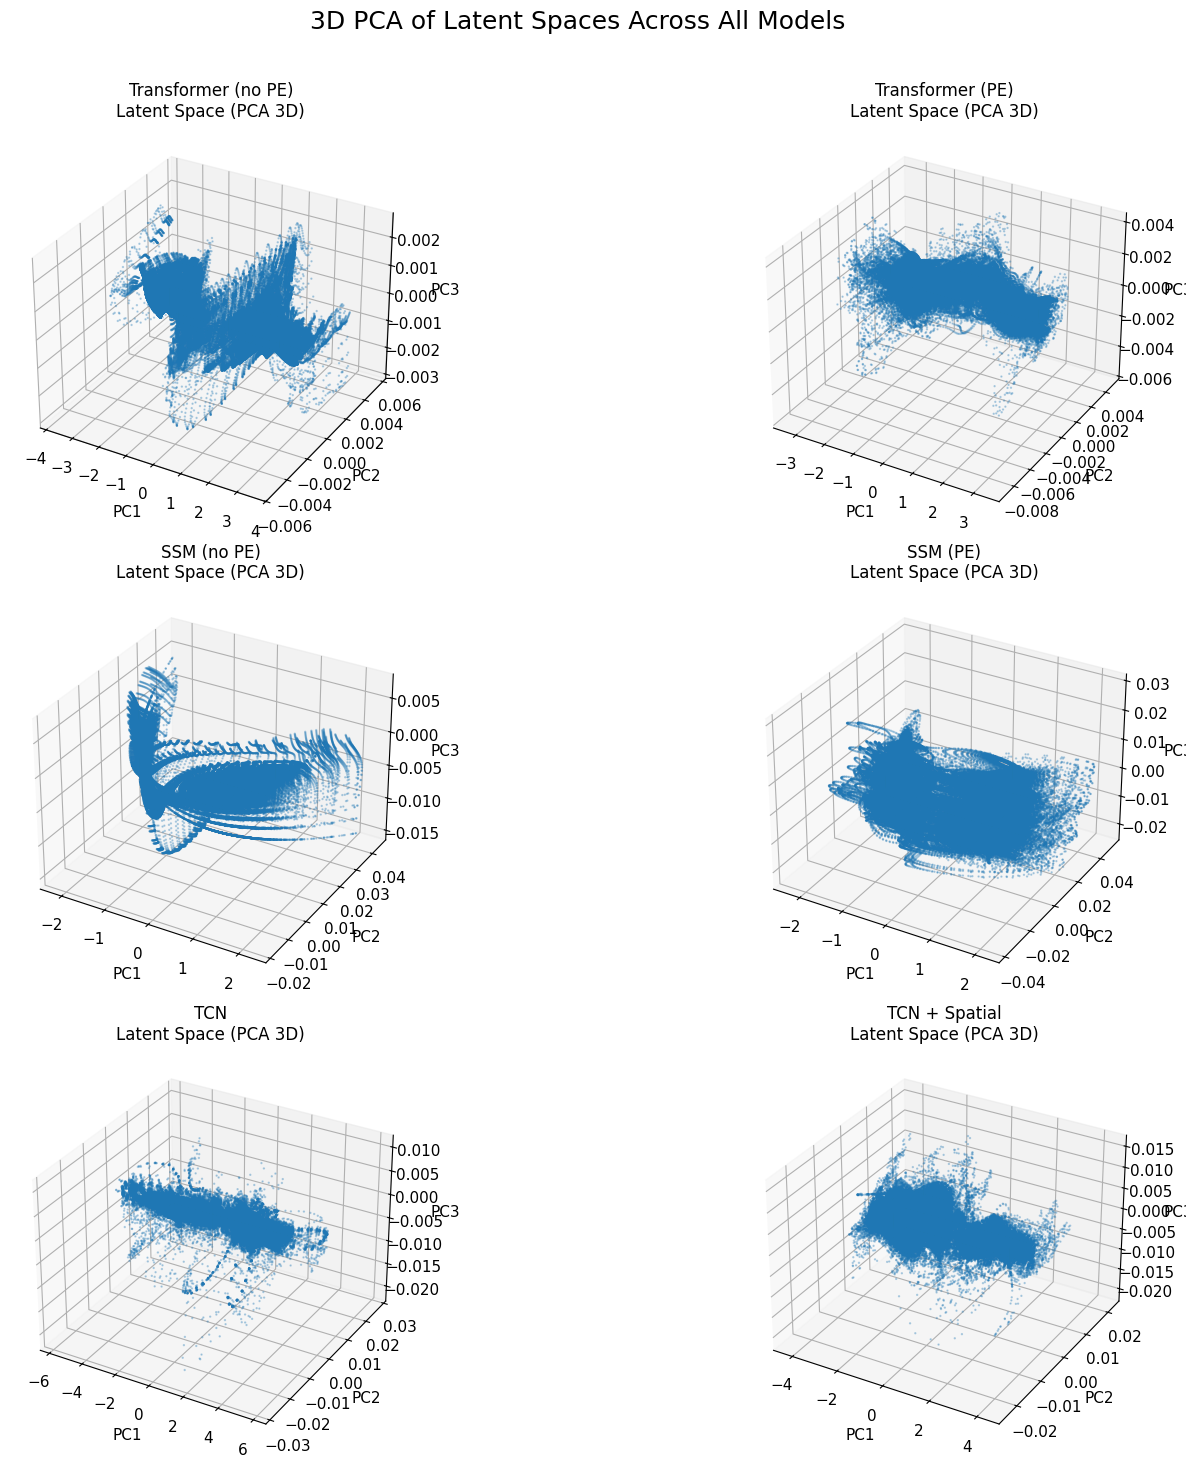

In [27]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# List of model names to match the order of your plots/results
model_names = list(results.keys())
n_models = len(model_names)
assert n_models == 6, "Expected 6 models!"

fig = plt.figure(figsize=(18, 14))
for i, name in enumerate(model_names):
    latent = results[name]['latent']  # shape: (n_windows, T, D_latent)
    latent_flat = latent.reshape(-1, latent.shape[-1])

    # Fit PCA on this model's latents
    pca = PCA(n_components=3)
    lat_3d = pca.fit_transform(latent_flat)

    ax = fig.add_subplot(3, 2, i+1, projection='3d')
    ax.scatter(lat_3d[:, 0], lat_3d[:, 1], lat_3d[:, 2], 
               s=0.5, alpha=0.3, c='tab:blue')
    ax.set_title(f'{name}\nLatent Space (PCA 3D)', fontsize=12)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')

plt.tight_layout()
plt.suptitle('3D PCA of Latent Spaces Across All Models', fontsize=18, y=1.04)
plt.show()

In [33]:
import numpy as np

def smoothness_relative(
    x,
    normalize_dim=True,
    normalize_time=True,
    reduction="mean",
    eps=1e-12,
):
    """
    Relative smoothness for (B, T, D).

    normalize_dim:
        Divide by D to avoid scaling with dimension.

    normalize_time:
        Average over time instead of summing.

    reduction:
        "mean", "sum", or "none"
    """
    x = np.asarray(x)
    B, T, D = x.shape

    diffs = x[:, 1:, :] - x[:, :-1, :]  # (B, T-1, D)

    # Euclidean squared norms
    num = np.sum(diffs**2, axis=2)      # (B, T-1)
    den = np.sum(x**2, axis=2)          # (B, T)

    if normalize_dim:
        num = num / D
        den = den / D

    if normalize_time:
        num = num.mean(axis=1)
        den = den.mean(axis=1)
    else:
        num = num.sum(axis=1)
        den = den.sum(axis=1)

    smooth = num / (den + eps)

    if reduction == "mean":
        return smooth.mean()
    elif reduction == "sum":
        return smooth.sum()
    else:
        return smooth

In [39]:
smoothness_relative(sliding_windows(test_full, TIME_WINDOW))

np.float64(0.0012769825327254855)

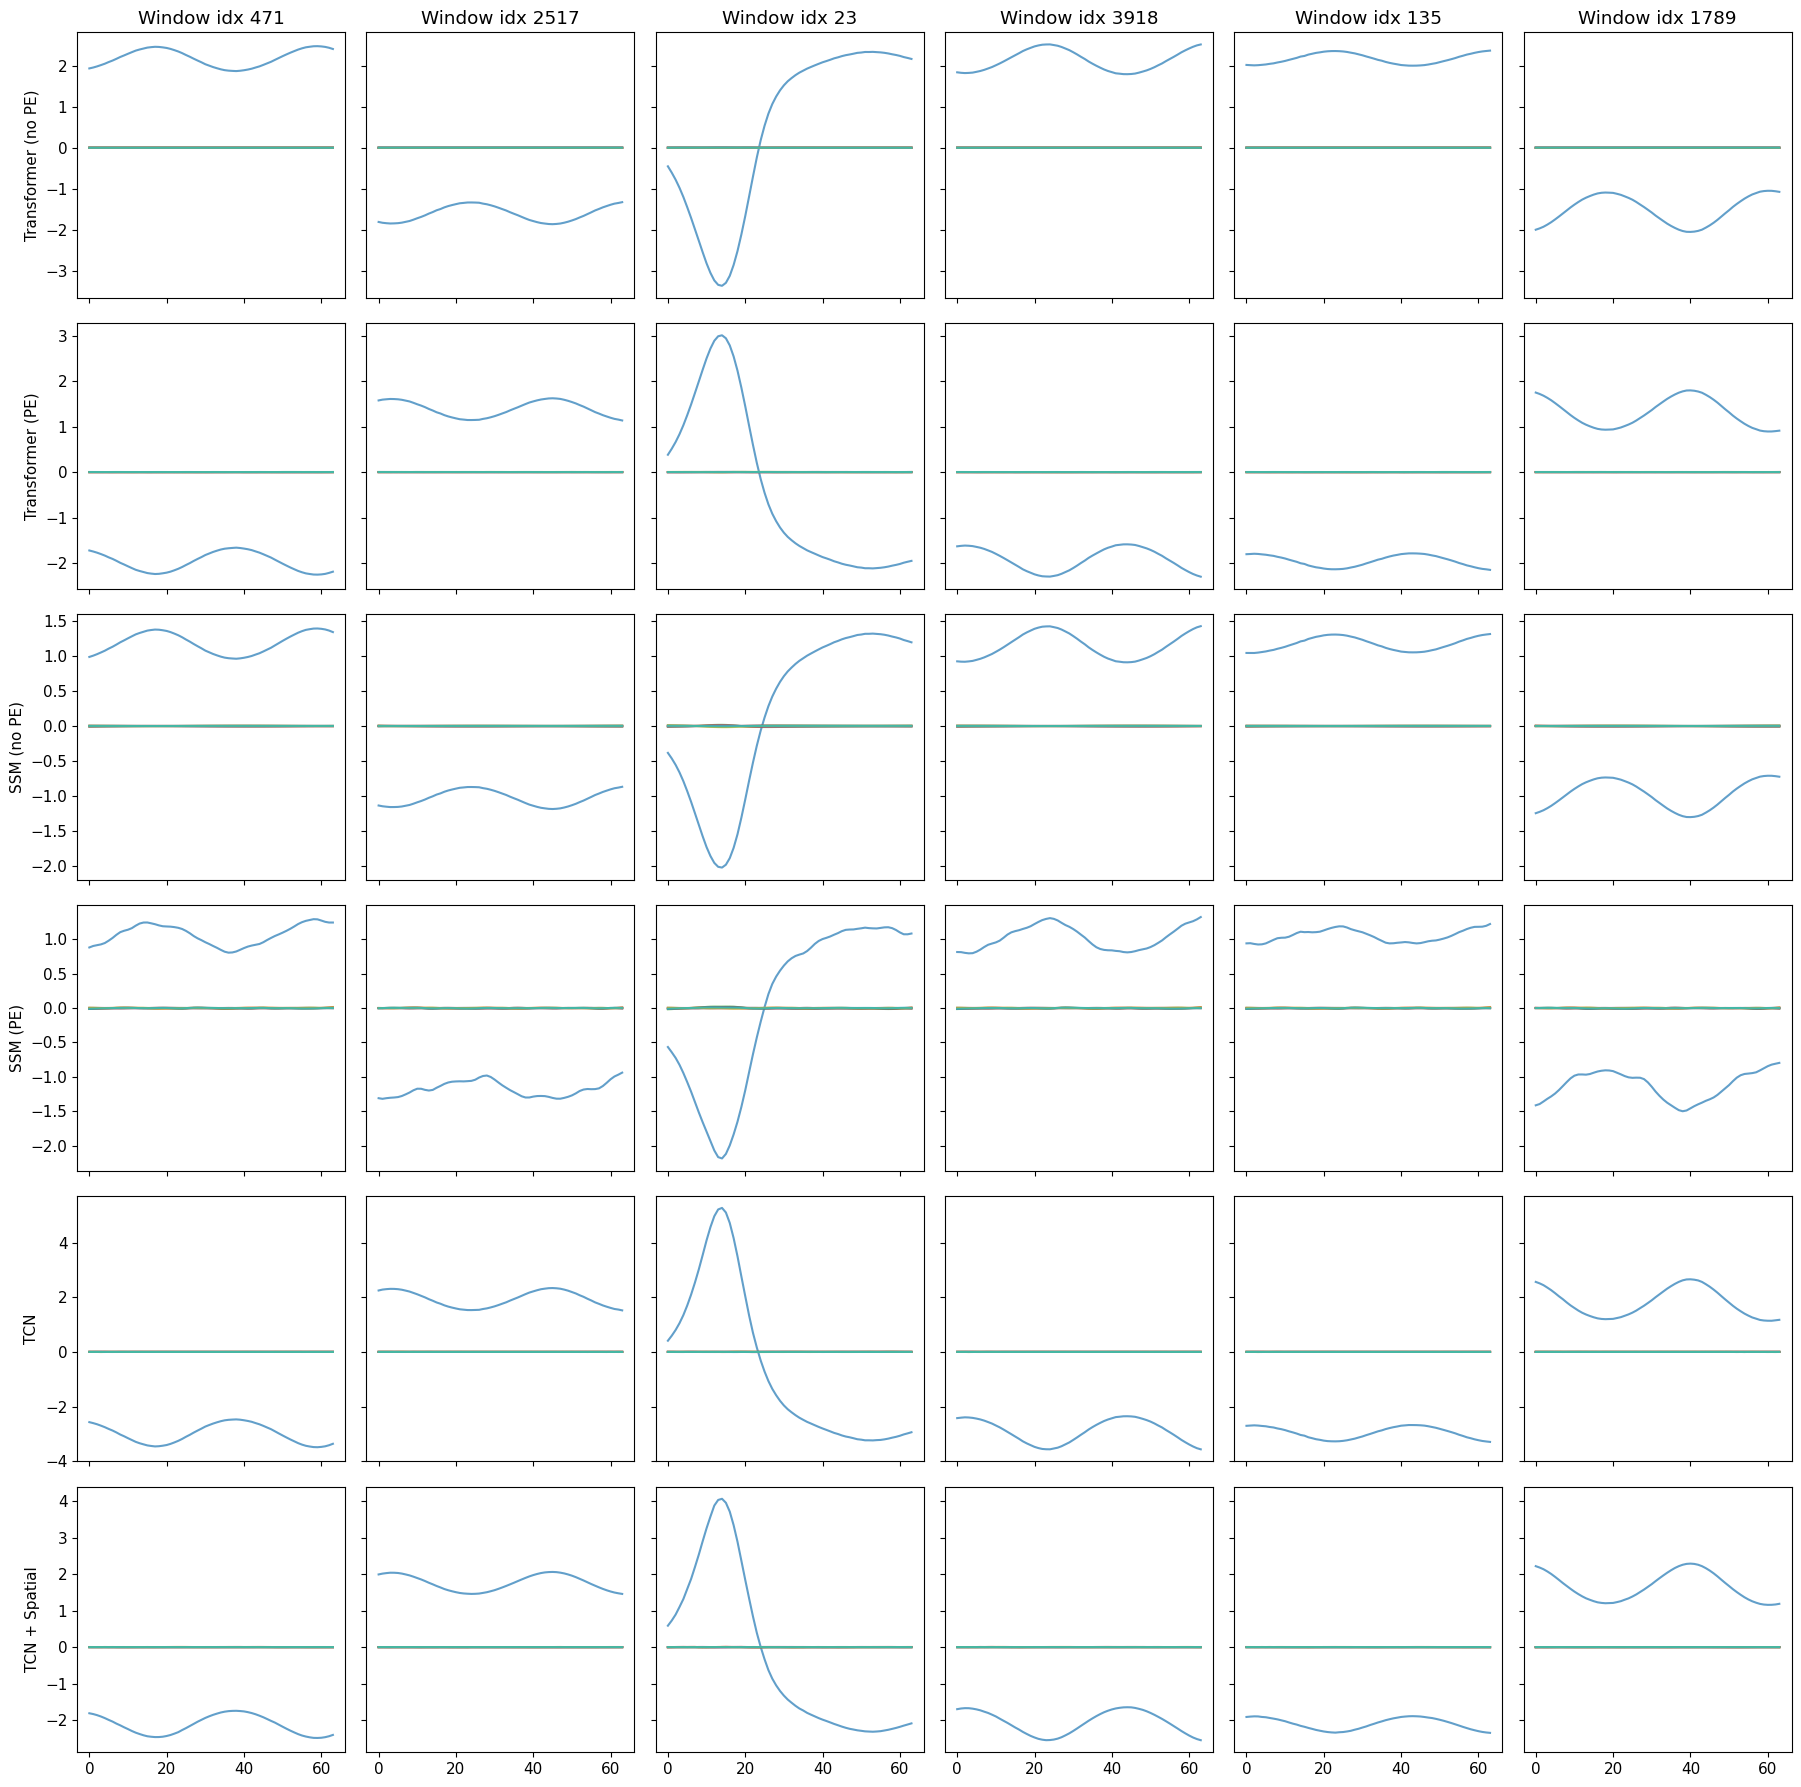

In [49]:
import numpy as np

model_names = list(results.keys())
n_models = len(model_names)
n_windows = 6  # pick 6 random indices

# Set figure up for 6x6 axes. If there are fewer than 6 models, repeat/leave blank.
fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(18, 18), sharex='col', sharey='row')

# Randomly select 6 sliding window indices (windows are on axis 0)
num_available_windows = min([results[m]['latent'].shape[0] for m in model_names])
rand_idx = np.random.choice(num_available_windows, size=6, replace=False)

for i, model in enumerate(model_names):
    latents = results[model]['latent']  # shape: (N, T, D)
    for j, idx in enumerate(rand_idx):
        ax = axes[i, j]
        for d in range(latents.shape[-1]):
            ax.plot(latents[idx, :, d], alpha=0.7)
        if i == 0:
            ax.set_title(f"Window idx {idx}")
        if j == 0:
            ax.set_ylabel(model)
        ax.tick_params(labelbottom=(i==5), labelleft=(j==0))
# Hide unused subplots if < 6 models
for i in range(len(model_names), 6):
    for j in range(6):
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

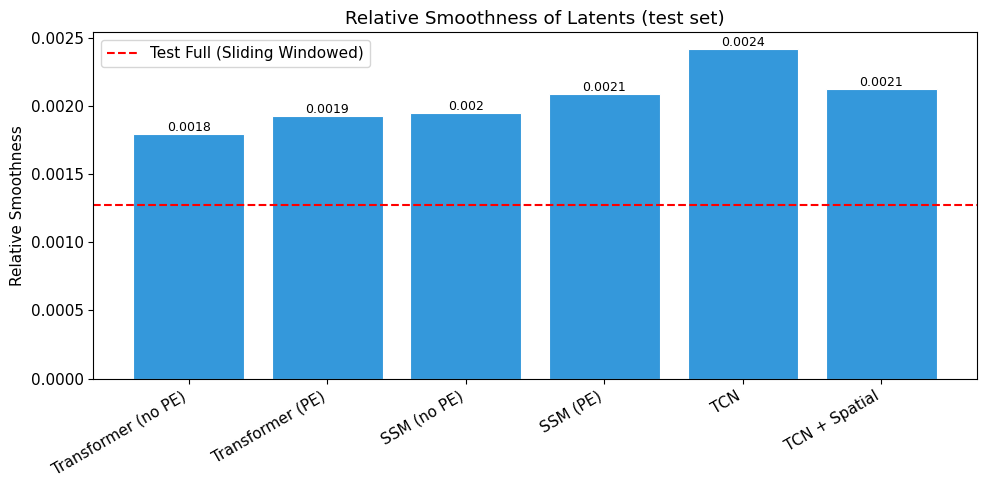

In [41]:
# Compute relative smoothness for each model
model_names = list(results.keys())
smoothness_values = [smoothness_relative(results[name]['latent']) for name in model_names]

# Get relative smoothness for test_full sliding windowed
test_smoothness = smoothness_relative(sliding_windows(test_full, TIME_WINDOW))

# Bar plot
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(model_names)), smoothness_values, color='#3498db', edgecolor='white', linewidth=0.8)
ax.axhline(test_smoothness, color='red', linestyle='--', label='Test Full (Sliding Windowed)')
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, rotation=30, ha='right')
ax.set_ylabel('Relative Smoothness')
ax.set_title('Relative Smoothness of Latents (test set)')
for bar, value in zip(bars, smoothness_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{value:.2g}', ha='center', va='bottom', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Results Comparison

In [ ]:
# Print summary table
print(f'{"Model":25s} {"Recon MSE":>12s} {"Params":>10s} {"Train (s)":>10s}')
print('-' * 60)
for name, r in results.items():
    print(f'{name:25s} {r["mse"]:12.6f} {r["n_params"]:10,} {r["train_time"]:10.1f}')

# Identify best model
best_name = min(results, key=lambda k: results[k]['mse'])
print(f'\nBest model: {best_name} (Recon MSE = {results[best_name]["mse"]:.6f})')

In [ ]:
# Bar chart of test reconstruction MSE
names = list(results.keys())
mses = [results[n]['mse'] for n in names]
colors = ['#2ecc71' if n == best_name else '#3498db' for n in names]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(names)), mses, color=colors, edgecolor='white', linewidth=0.8)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_ylabel('Test MSE (window reconstruction)')
ax.set_title('Architecture Comparison: Window Reconstruction on Lorenz (x only)')

for bar, mse_val in zip(bars, mses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{mse_val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Training Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, r in results.items():
    axes[0].plot(r['history']['recon_loss'], label=name, alpha=0.8)
    axes[1].plot(r['history']['reg_loss'], label=name, alpha=0.8)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Reconstruction Loss (MSE)')
axes[0].set_title('Reconstruction Loss'); axes[0].legend(fontsize=8)
axes[0].set_yscale('log')

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('FNN Regularization Loss')
axes[1].set_title('FNN Regularization Loss'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Latent Space Analysis

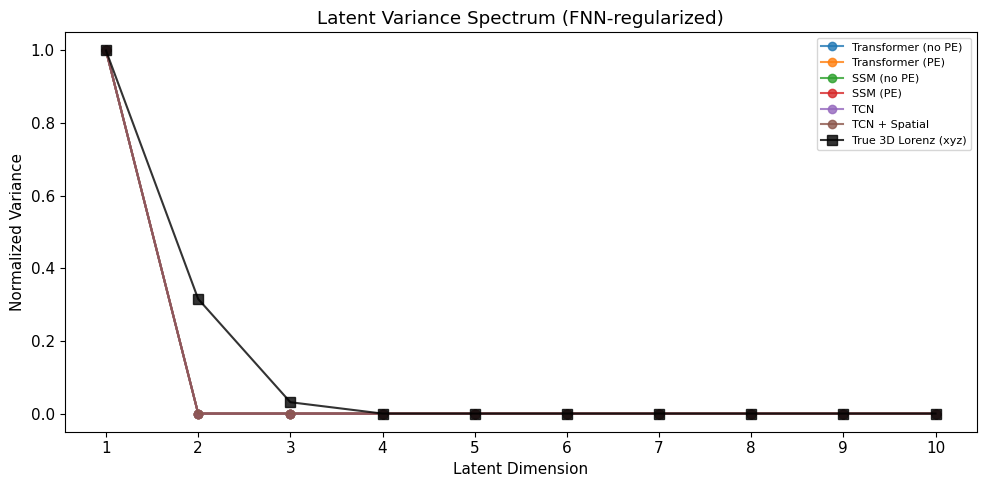

In [23]:
# Normalized variance spectrum of latent dimensions
fig, ax = plt.subplots(figsize=(10, 5))

for name, r in results.items():
    ax.plot(range(1, len(r['norm_var'])+1), r['norm_var'], 'o-', label=name, alpha=0.8)

# Add normalized variance of the full 3D Lorenz system for reference|
# Compute variance over the dataset (assume shape (n_samples, 3))
var_true = compute_variances(full_data_noisy.reshape(-1, 3), normalize=True)
var_true = np.pad(var_true, (0, N_LATENT - len(var_true)), mode='constant', constant_values=0)
ax.plot(range(1, N_LATENT+1), var_true, '-', color='k', marker='s', markersize=7, label='True 3D Lorenz (xyz)', alpha=0.8)

ax.set_xlabel('Latent Dimension')
ax.set_ylabel('Normalized Variance')
ax.set_title('Latent Variance Spectrum (FNN-regularized)')
ax.legend(fontsize=8)
# ax.set_yscale('log')
ax.set_xticks(range(1, N_LATENT+1))
plt.tight_layout()
plt.show()

In [ ]:
# 2D latent projections (first two principal latent dims)
from sklearn.decomposition import PCA

n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(4*n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, r) in zip(axes, results.items()):
    lat = r['latent']
    # Flatten per-timestep latent: (n_windows, T, D') -> (n_windows*T, D')
    lat_flat = lat.reshape(-1, lat.shape[-1])
    pca = PCA(n_components=2)
    lat_2d = pca.fit_transform(lat_flat)
    ax.scatter(lat_2d[:, 0], lat_2d[:, 1], s=0.5, alpha=0.3, c='tab:blue')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

fig.suptitle('Latent Space (PCA projection)', y=1.02)
plt.tight_layout()
plt.show()

## 7. Reconstruction Quality

In [ ]:
# Reconstructed vs true (using middle time step of each window)
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(4*n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, r) in zip(axes, results.items()):
    # Compare the middle time step of each window
    mid = TIME_WINDOW // 2
    recon_mid = r['recon'][:, mid, 0]
    true_mid = r['x_true'][:, mid, 0]
    # Subsample for clarity
    n_plot = min(2000, len(recon_mid))
    idx = np.random.choice(len(recon_mid), n_plot, replace=False)
    ax.scatter(true_mid[idx], recon_mid[idx], s=1, alpha=0.3)
    lims = [true_mid.min(), true_mid.max()]
    ax.plot(lims, lims, 'r--', lw=0.8, alpha=0.5)
    ax.set_title(f'{name}\nMSE={r["mse"]:.4f}', fontsize=9)
    ax.set_xlabel('True'); ax.set_ylabel('Reconstructed')
    ax.set_aspect('equal')

fig.suptitle('Window Reconstruction: True vs Reconstructed (mid-window step)', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Time series reconstruction for one test trajectory
fig, axes = plt.subplots(len(results), 1, figsize=(14, 3*len(results)), sharex=True)

# Use first test trajectory
test_single = test_data[0]  # (T, 1)
t_plot = 200  # show first 200 windows

for ax, (name, r) in zip(axes, results.items()):
    model = r['model']
    recon_single = model.reconstruct(test_single)  # (n_windows, TIME_WINDOW, 1)
    test_std_local = model._standardize(test_single)

    # Compare the last step of each reconstructed window with the true signal
    recon_last = recon_single[:t_plot, -1, 0]
    true_vals = test_std_local[TIME_WINDOW-1:TIME_WINDOW-1+t_plot, 0]

    ax.plot(true_vals, 'k-', lw=1, label='True', alpha=0.8)
    ax.plot(recon_last, '--', lw=1, label='Reconstructed (last step)', alpha=0.8)
    ax.set_ylabel('x (std)')
    ax.set_title(name, fontsize=10)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time step')
fig.suptitle('Window Reconstruction on Test Trajectory (last step of each window)', y=1.01)
plt.tight_layout()
plt.show()

## 8. Autoregressive Trajectory Prediction

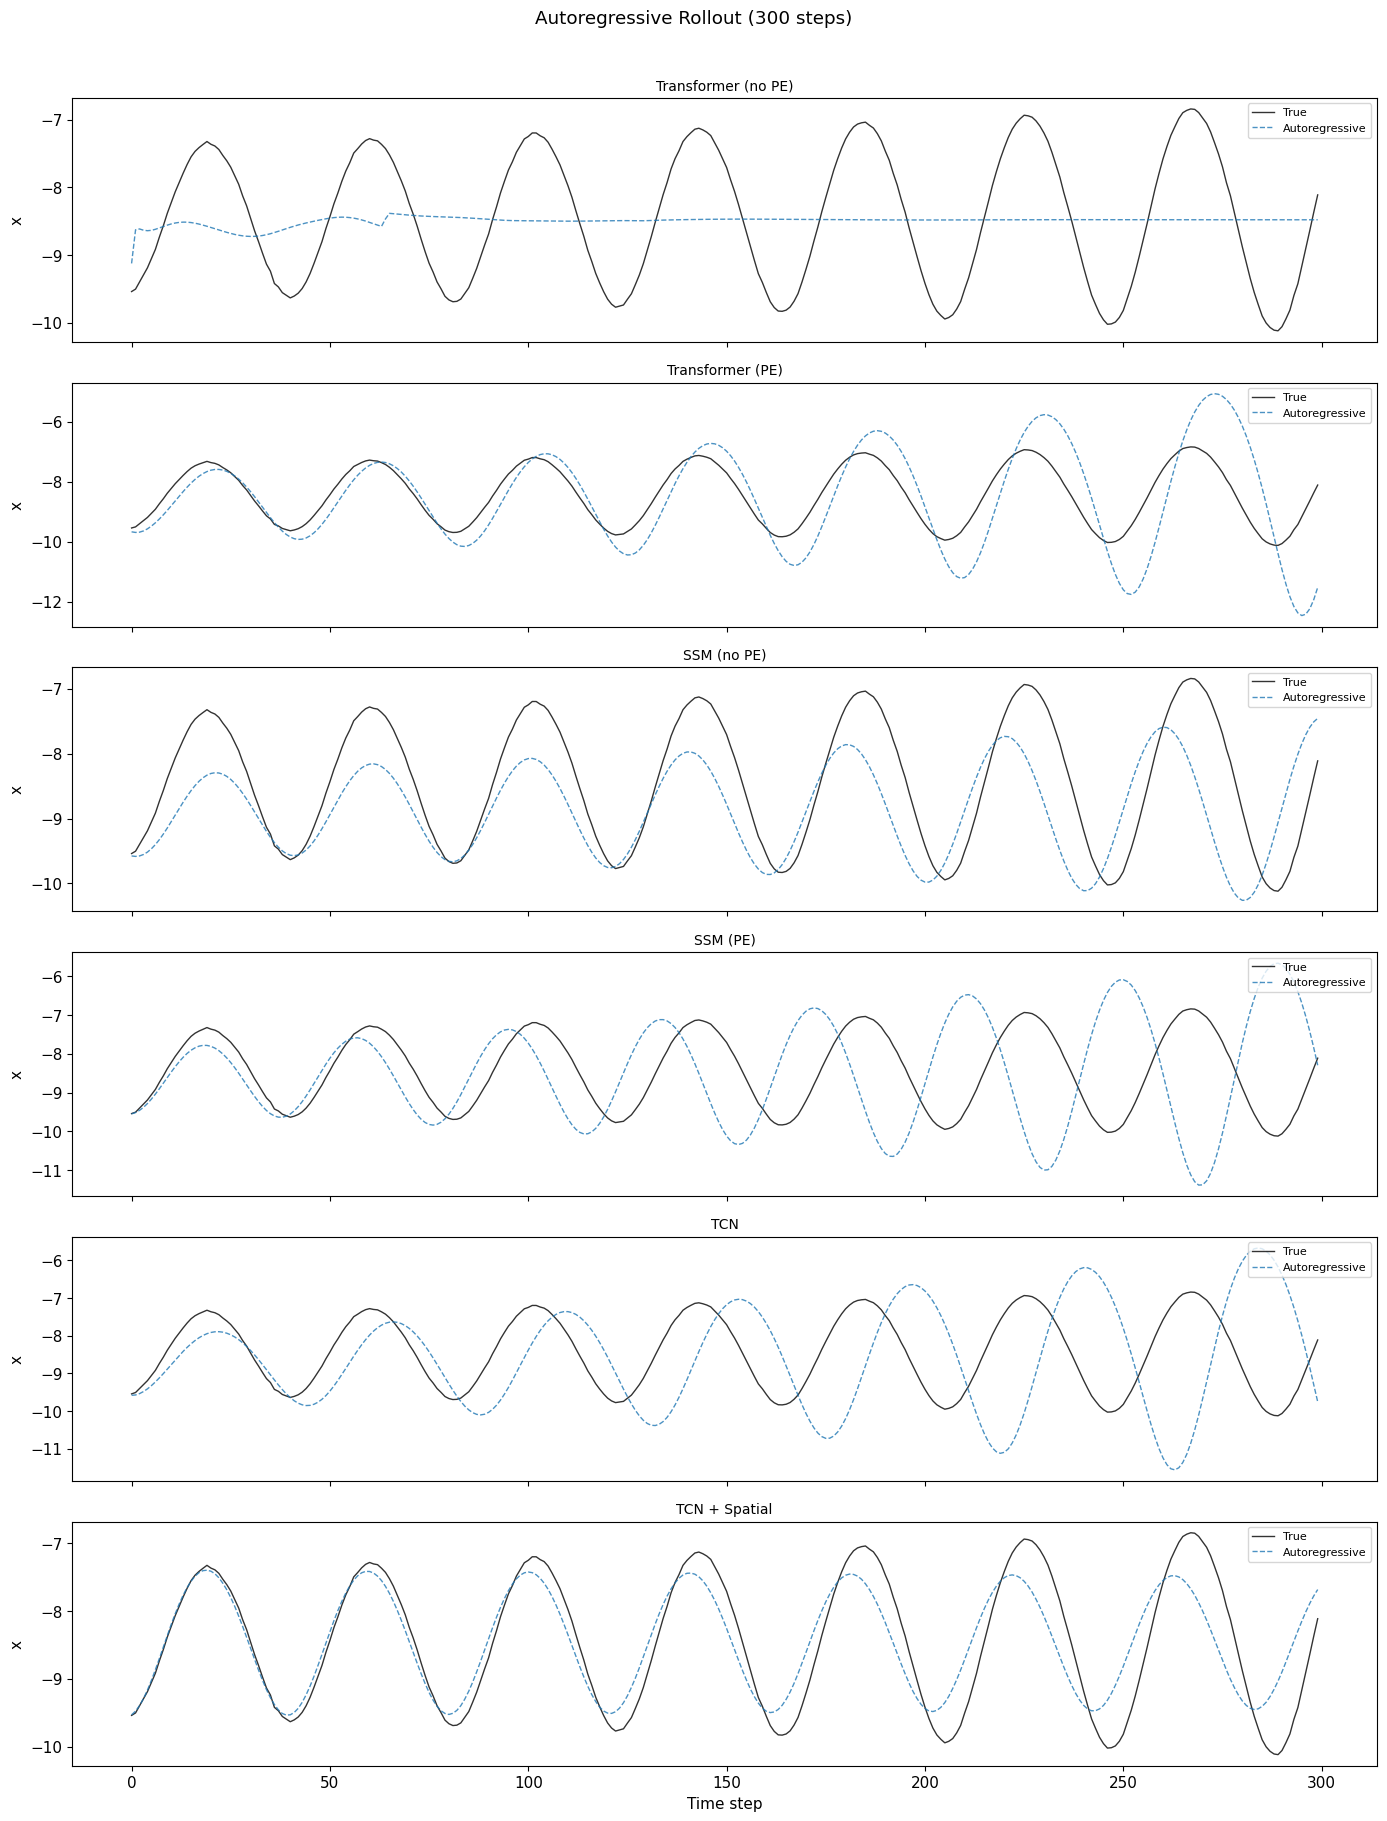

In [14]:
# Autoregressive rollout from seed
N_ROLLOUT = 300  # steps to predict forward
test_traj = test_data[0]  # (T, 1)

fig, axes = plt.subplots(len(results), 1, figsize=(14, 3*len(results)), sharex=True)

for ax, (name, r) in zip(axes, results.items()):
    model = r['model']
    # Seed with first TIME_WINDOW points, predict forward
    seed = test_traj[:TIME_WINDOW + 50]  # give a bit extra for context
    pred_traj = model.predict_trajectory(seed, n_steps=N_ROLLOUT)

    # Ground truth (un-standardized)
    true_traj = test_traj[TIME_WINDOW + 50 : TIME_WINDOW + 50 + N_ROLLOUT, 0]
    n_compare = min(len(true_traj), len(pred_traj))

    ax.plot(true_traj[:n_compare], 'k-', lw=1, label='True', alpha=0.8)
    ax.plot(pred_traj[:n_compare, 0], '--', lw=1, label='Autoregressive', alpha=0.8)
    ax.set_ylabel('x')
    ax.set_title(name, fontsize=10)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time step')
fig.suptitle(f'Autoregressive Rollout ({N_ROLLOUT} steps)', y=1.01)
plt.tight_layout()
plt.show()

## 9. FNN Regularization Sweep (Best Architecture)

Sweep the FNN regularization strength on the best-performing architecture
to find the optimal trade-off between prediction accuracy and latent
structure.

In [ ]:
# FNN sweep on the best architecture
best_cfg = model_configs[best_name]
# lambda_values = [0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
# lambda_values = [0, 1e-3, 1e-1]
lambda_values = [1e-3]

sweep_results = {'lambda': [], 'mse': [], 'norm_var': []}

for lam in lambda_values:
    print(f'  lambda={lam} ...', end=' ')
    reg = FNN(lam) if lam > 0 else None
    model = best_cfg['class'](
        n_latent=N_LATENT,
        time_window=TIME_WINDOW,
        n_features=N_FEATURES,
        random_state=SEED,
        latent_regularizer=reg,
        **best_cfg['kwargs'],
    )
    model.fit(train_data, train_steps=TRAIN_STEPS, batch_size=BATCH_SIZE,
              learning_rate=LEARNING_RATE, verbose=1, optimizer='adamw')

    recon = model.reconstruct(test_data)
    test_std = model._standardize(test_data)
    x_true = sliding_windows(test_std, TIME_WINDOW)
    mse = float(np.mean((recon - x_true) ** 2))

    latent = model.transform(test_data)
    # Flatten per-timestep latent: (n_windows, T, D') -> (n_windows*T, D')
    latent_flat = latent.reshape(-1, latent.shape[-1])
    norm_var = compute_variances(latent_flat, normalize=True)

    sweep_results['lambda'].append(lam)
    sweep_results['mse'].append(mse)
    sweep_results['norm_var'].append(norm_var)
    print(f'Recon MSE={mse:.6f}')

print('Sweep complete.')

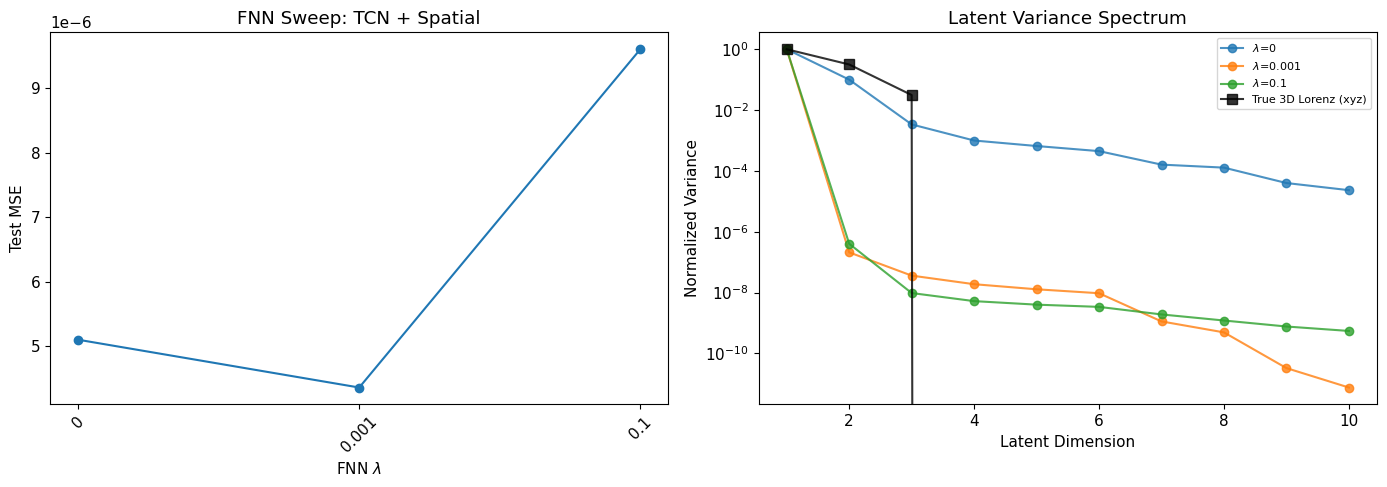

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE vs lambda
x_labels = [str(v) for v in sweep_results['lambda']]
axes[0].plot(x_labels, sweep_results['mse'], 'o-', color='tab:blue')
axes[0].set_xlabel(r'FNN $\lambda$')
axes[0].set_ylabel('Test MSE')
axes[0].set_title(f'FNN Sweep: {best_name}')
axes[0].tick_params(axis='x', rotation=45)

# Variance spectrum vs lambda
for lam, nv in zip(sweep_results['lambda'], sweep_results['norm_var']):
    axes[1].plot(range(1, len(nv)+1), nv, 'o-', label=f'$\\lambda$={lam}', alpha=0.8)
# plot the true variance spectrum
axes[1].plot(range(1, N_LATENT+1), var_true, '-', color='k', marker='s', markersize=7, label='True 3D Lorenz (xyz)', alpha=0.8)
axes[1].set_xlabel('Latent Dimension')
axes[1].set_ylabel('Normalized Variance')
axes[1].set_title('Latent Variance Spectrum')
axes[1].set_yscale('log')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [31]:
# import loss amplification
from JacobianODE.fnn import loss_amplification

In [42]:
loss_amplification(torch.from_numpy(full_data_noisy[:n_train]), torch.from_numpy(train_data), n_neighbors=2, max_T=5, normalize=True)

tensor(1.3185e-08, dtype=torch.float64)

In [32]:
loss_amplification(torch.from_numpy(train_data), torch.from_numpy(train_data), n_neighbors=2, max_T=5, normalize=True)

tensor(2.9507e-05, dtype=torch.float64)

In [ ]:
latent_train = model.transform(train_data)
# Flatten per-timestep: (n_windows, T, D') -> (n_windows*T, D')
latent_train_flat = latent_train.reshape(-1, latent_train.shape[-1])
loss_amplification(torch.from_numpy(latent_train_flat), torch.from_numpy(train_data), n_neighbors=2, max_T=5, normalize=True)

In [ ]:
latent_test = model.transform(test_data)
latent_test_flat = latent_test.reshape(-1, latent_test.shape[-1])
loss_amplification(torch.from_numpy(latent_test_flat), torch.from_numpy(test_data), n_neighbors=2, max_T=5, normalize=True)

In [ ]:
laten_train = model.transform(train_data)
# Flatten per-timestep: (n_windows, T, D') -> (n_windows*T, D')
laten_train_flat = laten_train.reshape(-1, laten_train.shape[-1])
# do pca to 2 components
pca = PCA(n_components=2)
laten_train_2d = pca.fit_transform(laten_train_flat)
plt.scatter(laten_train_2d[:, 0], laten_train_2d[:, 1], s=0.5, alpha=0.3, c='tab:blue')

## 10. Partial Observations with D=2

Repeat the comparison observing both $x$ and $y$ to see how extra
information affects each architecture.

In [ ]:
# Partial observation: (x, y) -> D=2
partial_data_2d = full_data_noisy[:, :, :2]  # (num_ics, T, 2)
train_data_2d = partial_data_2d[:n_train]
test_data_2d = partial_data_2d[n_train:]

results_2d = OrderedDict()

for name, cfg in model_configs.items():
    print(f'Training: {name} (D=2) ...', end=' ')
    model = cfg['class'](
        n_latent=N_LATENT,
        time_window=TIME_WINDOW,
        n_features=2,
        random_state=SEED,
        latent_regularizer=FNN(FNN_STRENGTH),
        **cfg['kwargs'],
    )
    model.fit(train_data_2d, train_steps=TRAIN_STEPS, batch_size=BATCH_SIZE,
              learning_rate=LEARNING_RATE, verbose=0, optimizer='adamw')

    recon = model.reconstruct(test_data_2d)
    test_std = model._standardize(test_data_2d)
    x_true = sliding_windows(test_std, TIME_WINDOW)
    mse = float(np.mean((recon - x_true) ** 2))

    results_2d[name] = {'mse': mse, 'n_params': model.count_parameters()}
    print(f'Recon MSE={mse:.6f}')

print()
# Comparison table: D=1 vs D=2
print(f'{"Model":25s} {"MSE (D=1)":>12s} {"MSE (D=2)":>12s}')
print('-' * 52)
for name in results.keys():
    print(f'{name:25s} {results[name]["mse"]:12.6f} {results_2d[name]["mse"]:12.6f}')

In [ ]:
# Side-by-side bar chart: D=1 vs D=2
names = list(results.keys())
mse_1d = [results[n]['mse'] for n in names]
mse_2d = [results_2d[n]['mse'] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, mse_1d, width, label='D=1 (x only)', color='#3498db')
ax.bar(x + width/2, mse_2d, width, label='D=2 (x, y)', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_ylabel('Test MSE')
ax.set_title('Architecture Comparison: D=1 vs D=2 Partial Observations')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Summary

In [ ]:
print('='*70)
print('FINAL SUMMARY')
print('='*70)
print(f'\nTask: Window reconstruction of Lorenz system from partial observations')
print(f'Latent dim: {N_LATENT}, Window: {TIME_WINDOW}, FNN lambda: {FNN_STRENGTH}')
print(f'Training: {TRAIN_STEPS} epochs, lr={LEARNING_RATE}\n')

print(f'{"Model":25s} {"MSE (D=1)":>12s} {"MSE (D=2)":>12s} {"Params":>10s} {"Time (s)":>10s}')
print('-' * 72)
for name in results.keys():
    print(f'{name:25s} {results[name]["mse"]:12.6f} {results_2d[name]["mse"]:12.6f} '
          f'{results[name]["n_params"]:10,} {results[name]["train_time"]:10.1f}')

best_1d = min(results, key=lambda k: results[k]['mse'])
best_2d = min(results_2d, key=lambda k: results_2d[k]['mse'])
print(f'\nBest (D=1): {best_1d}  (Recon MSE={results[best_1d]["mse"]:.6f})')
print(f'Best (D=2): {best_2d}  (Recon MSE={results_2d[best_2d]["mse"]:.6f})')